In [1]:
import os, time, json, warnings
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report, ConfusionMatrixDisplay
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding
warnings.filterwarnings('ignore', message='Was asked to gather along dimension 0')

DATA_DIR = '/kaggle/input/datasets/pavithra1mj/bert-model-for-dataset2'
OUT_DIR = '/kaggle/working'
MODEL = 'bert-base-uncased'
EPOCHS = 10
SEED = 42

In [2]:
exts = ('.csv', '.tsv', '.txt', '.xlsx', '.xls', '.json', '.jsonl', '.parquet')
root = DATA_DIR if os.path.exists(DATA_DIR) else '/kaggle/input'
cands = [os.path.join(r, f) for r, _, fs in os.walk(root) for f in fs if f.lower().endswith(exts)]
if os.path.isfile(DATA_DIR): cands = [DATA_DIR]
assert cands, os.listdir('/kaggle/input')
for c in cands: print(c, os.path.getsize(c))

/kaggle/input/datasets/pavithra1mj/bert-model-for-dataset2/labeled_bert_dataset by perplexity.json 857038


In [3]:
def load(path):
    e = os.path.splitext(path)[1].lower()
    if e == '.csv': return pd.read_csv(path)
    if e in ('.tsv', '.txt'): return pd.read_csv(path, sep='\t')
    if e in ('.xlsx', '.xls'): return pd.read_excel(path)
    if e == '.jsonl': return pd.read_json(path, lines=True)
    if e == '.json':
        with open(path) as f: raw = json.load(f)
        if isinstance(raw, dict): raw = next(v for v in raw.values() if isinstance(v, list))
        return pd.DataFrame(raw)
    return pd.read_parquet(path)

fp = cands[0]
df = load(fp)
print(fp, df.shape)
print(df.dtypes)
print(df.head())

/kaggle/input/datasets/pavithra1mj/bert-model-for-dataset2/labeled_bert_dataset by perplexity.json (7953, 2)
text     object
label    object
dtype: object
                                                text   label
0           Compare Donald Trump and Vladimir Putin.  NORMAL
1               They are both political narcissists.  NORMAL
2             Putin is more of an outright dictator.  NORMAL
3                    Donald Trump is not a dictator.  NORMAL
4  Every lawsuit that was against him, he still a...  NORMAL


In [4]:
cols = df.columns.tolist()
TEXT_COL = next((c for c in cols if c.lower() in ('text', 'sentence', 'transcript', 'content')), None)
LABEL_COL = next((c for c in cols if c.lower() in ('label', 'labels', 'class', 'category', 'target')), None)
if TEXT_COL is None:
    TEXT_COL = max([c for c in cols if c != LABEL_COL and df[c].dtype == object], key=lambda c: df[c].astype(str).str.len().mean())
if LABEL_COL is None:
    LABEL_COL = min([c for c in cols if c != TEXT_COL], key=lambda c: df[c].nunique())
print(TEXT_COL, LABEL_COL)

df = df[[TEXT_COL, LABEL_COL]].dropna().drop_duplicates(TEXT_COL).reset_index(drop=True)
le = LabelEncoder()
df['label'] = le.fit_transform(df[LABEL_COL].astype(str))
names = [str(x) for x in le.classes_]
NUM = len(names)
ID2LABEL = {i: n for i, n in enumerate(names)}
LABEL2ID = {n: i for i, n in ID2LABEL.items()}
print(df['label'].map(ID2LABEL).value_counts())

text label
label
NORMAL        4916
FILLER        1936
REPETITION     189
BOTH           189
Name: count, dtype: int64


In [5]:
strat = df['label'] if df['label'].value_counts().min() >= 10 else None
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=SEED, stratify=strat)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED, stratify=temp_df['label'] if strat is not None else None)
print(len(train_df), len(val_df), len(test_df))

5784 723 723


In [6]:
tok = AutoTokenizer.from_pretrained(MODEL)

class DS(torch.utils.data.Dataset):
    def __init__(self, d):
        self.enc = tok(d[TEXT_COL].astype(str).tolist(), truncation=True, max_length=128)
        self.y = d['label'].astype(int).tolist()
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.enc.items()}
        item['labels'] = self.y[i]
        return item

train_ds, val_ds, test_ds = DS(train_df), DS(val_df), DS(test_df)
collator = DataCollatorWithPadding(tok)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [7]:
def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    pw, rw, fw, _ = precision_recall_fscore_support(p.label_ids, preds, average='weighted', zero_division=0)
    pm, rm, fm, _ = precision_recall_fscore_support(p.label_ids, preds, average='macro', zero_division=0)
    return {'accuracy': accuracy_score(p.label_ids, preds), 'precision_weighted': pw, 'recall_weighted': rw, 'f1_weighted': fw,
            'precision_macro': pm, 'recall_macro': rm, 'f1_macro': fm}

model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=NUM, id2label=ID2LABEL, label2id=LABEL2ID)

n_gpu = max(1, torch.cuda.device_count())
warmup = int(0.1 * -(-len(train_ds) // (16 * n_gpu)) * EPOCHS)

args = TrainingArguments(
    output_dir=f'{OUT_DIR}/bert_out',
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=warmup,
    eval_strategy='epoch',
    save_strategy='no',
    logging_strategy='epoch',
    fp16=torch.cuda.is_available(),
    seed=SEED,
    report_to='none'
)

trainer = Trainer(model=model, args=args, train_dataset=train_ds, eval_dataset=val_ds,
                  data_collator=collator, compute_metrics=compute_metrics)

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [8]:
t0 = time.time()
trainer.train()
train_time = time.time() - t0
print(train_time)

Epoch,Training Loss,Validation Loss,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted,Precision Macro,Recall Macro,F1 Macro
1,1.324532,0.558505,0.928077,0.882079,0.928077,0.903761,0.453504,0.490525,0.470805
2,0.400822,0.257000,0.958506,0.956195,0.958506,0.955477,0.863835,0.753124,0.792328
3,0.185284,0.277253,0.969571,0.968672,0.969571,0.966974,0.939317,0.795139,0.847715
4,0.112093,0.286034,0.965422,0.970125,0.965422,0.967019,0.827475,0.917750,0.865987
5,0.046065,0.315468,0.968188,0.972622,0.968188,0.969754,0.827799,0.905330,0.861184
6,0.040292,0.262499,0.973721,0.973682,0.973721,0.973691,0.885156,0.883637,0.884389
7,0.016393,0.378118,0.965422,0.971190,0.965422,0.967435,0.814447,0.903526,0.851800
8,0.016396,0.315341,0.968188,0.972085,0.968188,0.969619,0.835291,0.906117,0.866398
9,0.008904,0.296551,0.970954,0.974175,0.970954,0.972109,0.842313,0.907133,0.870967
10,0.003805,0.289394,0.975104,0.976819,0.975104,0.975709,0.867082,0.909445,0.886242


457.7014274597168


              precision    recall  f1-score   support

        BOTH       0.81      0.68      0.74        19
      FILLER       0.95      0.97      0.96       194
      NORMAL       0.99      0.98      0.99       491
  REPETITION       0.80      0.84      0.82        19

    accuracy                           0.97       723
   macro avg       0.89      0.87      0.88       723
weighted avg       0.97      0.97      0.97       723



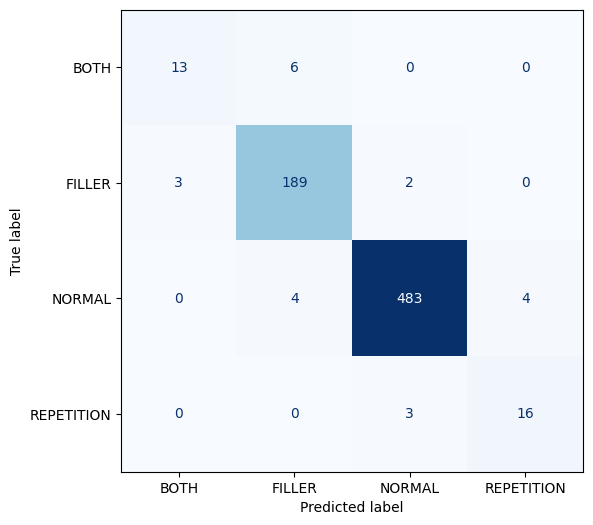

In [9]:
t1 = time.time()
pred = trainer.predict(test_ds)
eval_time = time.time() - t1

y_true = pred.label_ids
y_pred = np.argmax(pred.predictions, axis=1)
print(classification_report(y_true, y_pred, labels=range(NUM), target_names=names, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=range(NUM))
pd.DataFrame(cm, index=names, columns=names).to_csv(f'{OUT_DIR}/confusion_matrix.csv')
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay(cm, display_labels=names).plot(ax=ax, cmap='Blues', colorbar=False)
plt.savefig(f'{OUT_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
pw, rw, fw, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
pm, rm, fm, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)

summary = {
    'model': MODEL, 'epochs': EPOCHS, 'batch_size': 16, 'learning_rate': 2e-5,
    'train_samples': len(train_ds), 'val_samples': len(val_ds), 'test_samples': len(test_ds),
    'accuracy': accuracy_score(y_true, y_pred),
    'precision_weighted': pw, 'recall_weighted': rw, 'f1_weighted': fw,
    'precision_macro': pm, 'recall_macro': rm, 'f1_macro': fm,
    'train_wall_time_sec': round(train_time, 2), 'eval_wall_time_sec': round(eval_time, 2),
    'total_wall_time_sec': round(train_time + eval_time, 2)
}
pd.DataFrame([summary]).to_csv(f'{OUT_DIR}/evaluation_metrics.csv', index=False)

p_c, r_c, f_c, s_c = precision_recall_fscore_support(y_true, y_pred, labels=range(NUM), zero_division=0)
pd.DataFrame({'class': names, 'precision': p_c, 'recall': r_c, 'f1': f_c, 'support': s_c}).to_csv(f'{OUT_DIR}/per_class_metrics.csv', index=False)
pd.DataFrame(trainer.state.log_history).to_csv(f'{OUT_DIR}/training_log.csv', index=False)
print(pd.read_csv(f'{OUT_DIR}/evaluation_metrics.csv').T)

                                     0
model                bert-base-uncased
epochs                              10
batch_size                          16
learning_rate                  0.00002
train_samples                     5784
val_samples                        723
test_samples                       723
accuracy                      0.969571
precision_weighted            0.969375
recall_weighted               0.969571
f1_weighted                   0.969266
precision_macro               0.888001
recall_macro                  0.871062
f1_macro                      0.877981
train_wall_time_sec              457.7
eval_wall_time_sec                1.63
total_wall_time_sec             459.33


In [11]:
trainer.save_model(f'{OUT_DIR}/bert_finetuned')
tok.save_pretrained(f'{OUT_DIR}/bert_finetuned')
pd.DataFrame({'label': names, 'id': range(NUM)}).to_csv(f'{OUT_DIR}/label_map.csv', index=False)
print(os.listdir(OUT_DIR))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['confusion_matrix.csv', 'confusion_matrix.png', 'label_map.csv', 'training_log.csv', 'per_class_metrics.csv', 'evaluation_metrics.csv', 'bert_out', 'bert_finetuned', '__notebook__.ipynb']
